# Power Metering Failure Prediction

In [ ]:
import pandas as pd
import numpy as np
#import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
import sklearn as skl

import datetime
import math
import random
import glob # for finding pathnames matching a specified pattern
import os
#import cx_Oracle # Need Anaconda 32-bit. If your Anaconda is 64-bit, you need to install a 32-bit version. To install cx_Oracle: open Anaconda Prompt command window, and type "pip install cx_Oracle" to install Oracle library
import sqlalchemy
import pickle # save and load variables
import gc # garbage collection, release memory when deleting variables

from scipy import stats
from scipy.stats import norm, skew #for some statistics

import copy # use df_copy = copy.deepcopy(df) to copy a dataframe (e.g. called "df"), or use: df_copy = df.iloc[0:,0:], 
#but don't use df_copy = df (this is a "fake" copy by reference not by value, so changing value in df_copy will change df as well)

#pd.set_option("display.max_rows", None) # show all rows with scrollbar, don't use if there are many rows.
pd.set_option("display.max_rows", 1000) # show all rows with scrollbar, don't use if there are many rows.
pd.set_option("display.max_columns", None)

## 1. Data Preparation

In [ ]:
start_date = '20171010'
end_date = '20171030'
num_normal_meters = 30000 # number of normal meters for training

userid = ''
pwd =  ''
# Connect to database

ip = ''
port = 1
SID = ''

dsn = cx_Oracle.makedsn(ip, port, SID)
db_conn = cx_Oracle.connect(userid, pwd, dsn)
cursor = db_conn.cursor()

In [ ]:
import pyodbc
import pypyodbc
conn_string=''
conn = pypyodbc.connect(conn_string)
db_conn1 = pyodbc.connect(r'')

In [ ]:
oracle_engine = sqlalchemy.create_engine('oracle+cx_oracle://%s:%s@%s' % (userid, pwd, dsn))
#oracle_engine = sqlalchemy.create_engine('oracle://%s:%s@%s' % (userid, pwd, tns))

In [ ]:
# Define a function to combine files of meter failure

In [ ]:
def combine_files(folder_path,failure_label):
    all_files = glob.glob(folder_path + '/*')
    data_tmp = []
    for each_file in all_files:
        file_name = os.path.basename(each_file)
        file_tmp = pd.read_csv(each_file)
        failure_date = file_name[-12:-4]
        if len(file_tmp) == 0:
            file_tmp['FAILURE_DATE'] = []
        else:
            file_tmp['FAILURE_DATE'] = failure_date
            
        if len(file_tmp) !=0 and len(data_tmp) !=0:
            data_tmp = pd.concat([data_tmp,file_tmp],axis=0,ignore_index=True)
        elif len(file_tmp) !=0 and len(data_tmp) ==0:
            data_tmp = file_tmp
        else:
            continue
        data_tmp['FAILURE_LABEL'] = failure_label
    return data_tmp
        


In [ ]:
random.seed(10000)
folder_path = './Data/PowerFailure/power_failure_count_meters'
short_failure = combine_files(folder_path,'0')[['FAILURE_LABEL','FAILURE_DATE','MeterNo']]
folder_path = './Data/PowerFailure/long_power_fail_count_meters'
long_failure = combine_files(folder_path,'1')[['FAILURE_LABEL','FAILURE_DATE','MeterNo']]
folder_path = './Data/PowerFailure/self_check_daily'
selfcheck_failure = combine_files(folder_path,'2')[['FAILURE_LABEL','FAILURE_DATE','MeterNo']]

meter_failure = pd.concat([selfcheck_failure,long_failure,short_failure],axis=0,ignore_index=True)
# meter_failure = pd.concat([selfcheck_failure,long_failure],axis=0,ignore_index=True)
meter_failure.columns = meter_failure.columns.str.upper()

In [ ]:
meter_failure = meter_failure[(meter_failure['FAILURE_DATE'] >= start_date) & (meter_failure['FAILURE_DATE'] <= end_date)].reset_index(drop=True)

In [ ]:
# Select some normal meters from database

normal_meter = pd.read_sql("""select METERNO from *** 
                              where METERNO like '%LG'
                              and STATUS_CODE='Normal' 
                              and (SYSDATE - LASTBILLABLEREAD) <= 1 """,db_conn)
normal_meter = normal_meter.sample(n=num_normal_meters,replace=False).reset_index(drop=True)
normal_meter['FAILURE_LABEL'] = '0'
normal_meter['FAILURE_DATE'] = meter_failure[['FAILURE_DATE']].sample(n=len(normal_meter['METERNO']), replace=True).reset_index(drop=True)
normal_meter = normal_meter.iloc[:,[1,2,0]]

In [ ]:
meter_failure = pd.concat([meter_failure,normal_meter],axis=0)
meter_failure = meter_failure.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)

### Database query

In [ ]:
# Get meter, endpointid for meterno

meter = pd.read_sql("""select TO_CHAR(METERID) as METERID, TO_CHAR(METERNO) as METERNO from *** where METERNO like '%LG' """, db_conn)
endpointid = pd.read_sql("""select TO_CHAR(ENDPOINTID) as ENDPOINTID, TO_CHAR(METERID) as METERID from *** """, db_conn)

In [ ]:
meter_failure = pd.merge(meter_failure, meter, on=['METERNO'], how='inner')
meter_failure = pd.merge(meter_failure, endpointid, on=['METERID'], how='inner')
#meter_failure = meter_failure.dropna(axis=0, subset=['ENDPOINTID'])
meter_failure = meter_failure.dropna(axis=0)
meter_failure = meter_failure.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)
# re-order columns
meter_failure = meter_failure[['FAILURE_LABEL','FAILURE_DATE','METERNO','METERID','ENDPOINTID']]

In [ ]:
# Upload meter_failure to your EDW sandbox
# If meter_failure has been uploaded before, it will drop it and create a new one.

dtype_new = {c:sqlalchemy.types.VARCHAR(20) #(meter_failure[c].str.len().max())
             for c in meter_failure.columns[meter_failure.dtypes == 'object'].tolist()}
meter_failure.to_sql('meter_failure', oracle_engine, if_exists='replace', dtype=dtype_new, index=False)

##query_tmp="""alter table """ + userid + """.meter_failure ADD CONSTRAINT PK_MF PRIMARY KEY(ENDPOINTID)"""
##query_tmp="""create unique index idx_mf on """ + userid + """.meter_failure (ENDPOINTID)"""
##cursor.execute(query_tmp)

In [ ]:
# Outage Count
failure_dates = meter_failure['FAILURE_DATE'].unique()
outage_count = []
for failure_date in failure_dates:
    date_tmp = datetime.datetime.strptime(failure_date, '%Y%m%d') 
    failure_date_tmp = date_tmp.strftime('%Y%m%d')
    failure_date_tmp1 = (date_tmp - datetime.timedelta(days=1)).strftime('%Y%m%d')
    failure_date_tmp2 = (date_tmp - datetime.timedelta(days=30)).strftime('%Y%m%d')
    meters = meter_failure[meter_failure['FAILURE_DATE']==failure_date]
    meters_endpointid = meters['ENDPOINTID'].values
    for j in range(len(meters_endpointid)):
        query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, SUM(CASE WHEN INTERVALSTATUSID=0 THEN 0 ELSE 1 END) as OUTAGE_COUNT
                       from ***
                       where ENDPOINTID = """ + meters_endpointid[j] + """ and INTERVALCHANNELNO = 1
                       and DATADEFINITIONID = 7077
                       and INTERVALSTATUSID != 0
                       and INTERVALSTARTDATE <= TO_DATE('""" + failure_date_tmp1 + """','YYYYMMDD')
                       and INTERVALSTARTDATE >= TO_DATE('""" + failure_date_tmp2 + """','YYYYMMDD')
                       group by ENDPOINTID"""
        data_tmp = pd.read_sql(query_tmp,db_conn)
        if len(outage_count) != 0 and len(data_tmp) !=0:
            outage_count = pd.concat([outage_count,data_tmp],axis=0,ignore_index=True)
        elif len(outage_count) == 0 and len(data_tmp) != 0:
            outage_count = data_tmp
        else:
            continue
        if j%100==0: print('j = ',j)
    print(failure_date)
query_tmp

In [ ]:
# IDR Outage Count
failure_dates = meter_failure['FAILURE_DATE'].unique()
idr_outage_count = []
for failure_date in failure_dates:
    date_tmp = datetime.datetime.strptime(failure_date, '%Y%m%d') 
    failure_date_tmp = date_tmp.strftime('%Y%m%d')
    failure_date_tmp1 = (date_tmp - datetime.timedelta(days=1)).strftime('%Y%m%d')
    meters = meter_failure[meter_failure['FAILURE_DATE']==failure_date]
    meters_endpointid = meters['ENDPOINTID'].values
    for j in range(len(meters_endpointid)):
        query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, max(VALUEDEC) as IDR_OUTAGE_COUNT
                       from ***
                       where ENDPOINTID = """ + meters_endpointid[j] + """ and DATADEFINITIONID = 1090
                       and READINGDATE <= TO_DATE('""" + failure_date_tmp1 + """','YYYYMMDD')
                       group by ENDPOINTID"""
        data_tmp = pd.read_sql(query_tmp,db_conn)
        if len(idr_outage_count) != 0 and len(data_tmp) !=0:
            idr_outage_count = pd.concat([idr_outage_count,data_tmp],axis=0,ignore_index=True)
        elif len(idr_outage_count) == 0 and len(data_tmp) != 0:
            idr_outage_count = data_tmp
        else:
            continue
        if j%100==0: print('j = ',j)
    print(failure_date)
query_tmp

In [ ]:
# Total Event Count
failure_dates = meter_failure['FAILURE_DATE'].unique()
total_event_count = []
for failure_date in failure_dates:
    date_tmp = datetime.datetime.strptime(failure_date, '%Y%m%d') 
    failure_date_tmp = date_tmp.strftime('%Y%m%d')
    failure_date_tmp1 = (date_tmp - datetime.timedelta(days=1)).strftime('%Y%m%d')
    meters = meter_failure[meter_failure['FAILURE_DATE']==failure_date]
    meters_endpointid = meters['ENDPOINTID'].values
    for j in range(len(meters_endpointid)):
        query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, count(EVENTTYPEID) as TOTAL_EVENT_COUNT
                       from ***
                       where ENDPOINTID = """ + meters_endpointid[j] + """ and EVENTDATE <= TO_DATE('""" + failure_date_tmp1 + """','YYYYMMDD')
                       group by ENDPOINTID"""
        data_tmp = pd.read_sql(query_tmp,db_conn)
        if len(total_event_count) != 0 and len(data_tmp) !=0:
            total_event_count = pd.concat([total_event_count,data_tmp],axis=0,ignore_index=True)
        elif len(total_event_count) == 0 and len(data_tmp) != 0:
            total_event_count = data_tmp
        else:
            continue
        if j%100==0: print('j = ',j)
    print(failure_date)
query_tmp

In [ ]:
# Negative Event Count

negative_event_types = """ (select EVENTTYPEID from ***
where lower(NAME) like '%fail%' or lower(NOTES) like '%fail%'
or lower(NAME) like '%failure%' or lower(NOTES) like '%failure%'
or lower(NAME) like '%error%' or lower(NOTES) like '%error%'
or lower(NAME) like '% down%' or lower(NOTES) like '% down%'
or lower(NAME) like '%outage%' or lower(NOTES) like '%outage%'
or lower(NAME) like '%disable%' or lower(NOTES) like '%disable%'
or lower(NAME) like '%invalid%' or lower(NOTES) like '%invalid%'
or lower(NAME) like '%dead%' or lower(NOTES) like '%dead%'
or lower(NAME) like '%stop%' or lower(NOTES) like '%stop%'
or lower(NAME) like '%loss%' or lower(NOTES) like '%loss%'
or lower(NAME) like '%lost%' or lower(NOTES) like '%lost%'
or lower(NAME) like '%miss%' or lower(NOTES) like '%miss%'
or lower(NAME) like '%overload%' or lower(NOTES) like '%overload%'
or lower(NAME) like '%restore%' or lower(NOTES) like '%restore%'
or lower(NAME) like '%extreme%' or lower(NOTES) like '%extreme%'
or lower(NAME) like '%exceeded%' or lower(NOTES) like '%exceeded%'
or lower(NAME) like '%disconnect%' or lower(NOTES) like '%disconnect%'
or lower(NAME) like '%reboot%' or lower(NOTES) like '%reboot%'
or lower(NAME) like '%restart%' or lower(NOTES) like '%restart%'
or lower(NAME) like '%detected%' or lower(NOTES) like '%detected%'
or lower(NAME) like '%interrupt%' or lower(NOTES) like '%interrupt%') """

failure_dates = meter_failure['FAILURE_DATE'].unique()
negative_event_count = []
for failure_date in failure_dates:
    date_tmp = datetime.datetime.strptime(failure_date, '%Y%m%d') 
    failure_date_tmp = date_tmp.strftime('%Y%m%d')
    failure_date_tmp1 = (date_tmp - datetime.timedelta(days=1)).strftime('%Y%m%d')
    meters = meter_failure[meter_failure['FAILURE_DATE']==failure_date]
    meters_endpointid = meters['ENDPOINTID'].values
    for j in range(len(meters_endpointid)):
        query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, count(EVENTTYPEID) as NEGATIVE_EVENT_COUNT
                       from ***
                       where ENDPOINTID = """ + meters_endpointid[j] + """ and EVENTDATE <= TO_DATE('""" + failure_date_tmp1 + """','YYYYMMDD') 
                       and EVENTTYPEID in """ + negative_event_types + """
                       group by ENDPOINTID"""
        data_tmp = pd.read_sql(query_tmp,db_conn)
        if len(negative_event_count) != 0 and len(data_tmp) !=0:
            negative_event_count = pd.concat([negative_event_count,data_tmp],axis=0,ignore_index=True)
        elif len(negative_event_count) == 0 and len(data_tmp) != 0:
            negative_event_count = data_tmp
        else:
            continue
        if j%100==0: print('j = ',j)
    print(failure_date)
query_tmp

In [ ]:
# Voltage Standard Deviation
failure_dates = meter_failure['FAILURE_DATE'].unique()
voltage_std = []
for failure_date in failure_dates:
    date_tmp = datetime.datetime.strptime(failure_date, '%Y%m%d') 
    failure_date_tmp = date_tmp.strftime('%Y%m%d')
    failure_date_tmp1 = (date_tmp - datetime.timedelta(days=1)).strftime('%Y%m%d')
    failure_date_tmp2 = (date_tmp - datetime.timedelta(days=30)).strftime('%Y%m%d')
    meters = meter_failure[meter_failure['FAILURE_DATE']==failure_date]
    meters_endpointid = meters['ENDPOINTID'].values
    for j in range(len(meters_endpointid)):
        query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, ROUND(STDDEV(INTERVALVALUE),2) as VOLTAGE_STD
                       from ***
                       where ENDPOINTID = """ + meters_endpointid[j] + """ and INTERVALCHANNELNO = 1
                       and DATADEFINITIONID = 7077
                       and INTERVALSTARTDATE <= TO_DATE('""" + failure_date_tmp1 + """','YYYYMMDD')
                       and INTERVALSTARTDATE >= TO_DATE('""" + failure_date_tmp2 + """','YYYYMMDD')
                       group by ENDPOINTID"""
        data_tmp = pd.read_sql(query_tmp,db_conn)
        if len(voltage_std) != 0 and len(data_tmp) !=0:
            voltage_std = pd.concat([voltage_std,data_tmp],axis=0,ignore_index=True)
        elif len(voltage_std) == 0 and len(data_tmp) != 0:
            voltage_std = data_tmp
        else:
            continue
        if j%100==0: print('j = ',j)
    print(failure_date)
query_tmp

In [ ]:
# Temperature Max
failure_dates = meter_failure['FAILURE_DATE'].unique()
temperature_max = []
for failure_date in failure_dates:
    date_tmp = datetime.datetime.strptime(failure_date, '%Y%m%d') 
    failure_date_tmp = date_tmp.strftime('%Y%m%d')
    failure_date_tmp1 = (date_tmp - datetime.timedelta(days=1)).strftime('%Y%m%d')
    meters = meter_failure[meter_failure['FAILURE_DATE']==failure_date]
    meters_endpointid = meters['ENDPOINTID'].values
    for j in range(len(meters_endpointid)):
        query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, max(VALUEDEC) as TEMPERATURE_MAX
                       from ***
                       where ENDPOINTID = """ + meters_endpointid[j] + """ and DATADEFINITIONID = 2543
                       and READINGDATE <= TO_DATE('""" + failure_date_tmp1 + """','YYYYMMDD')
                       group by ENDPOINTID"""
        data_tmp = pd.read_sql(query_tmp,db_conn)
        if len(temperature_max) != 0 and len(data_tmp) !=0:
            temperature_max = pd.concat([temperature_max,data_tmp],axis=0,ignore_index=True)
        elif len(temperature_max) == 0 and len(data_tmp) != 0:
            temperature_max = data_tmp
        else:
            continue
        if j%100==0: print('j = ',j)
    print(failure_date)
query_tmp

In [ ]:
total_event_count.to_csv('total_event_count.csv')
negative_event_count.to_csv('negative_event_count.csv')
outage_count.to_csv('outage_count.csv')
temperature_max.to_csv('temperature_max.csv')
voltage_std.to_csv('voltage_std.csv')


In [ ]:
import pickle

# Saving the objects:
#with open('./Python_save_data_pkl/meter_failure.pkl', 'wb') as pkl:
#    pickle.dump([meter_failure, total_event_count, negative_event_count, outage_count, temperature_max, voltage_std], pkl)

# Getting back the objects:
with open('./Python_save_data_pkl/meter_failure.pkl','rb') as pkl:
    [meter_failure, total_event_count, negative_event_count, outage_count, temperature_max, voltage_std] = pickle.load(pkl)

In [ ]:
# Age
query_tmp = """select mf.METERNO, ede.DATE_DEPLOYED
               from *** ede
               inner join """ + userid + """.meter_failure mf
               on ede.METERNO=mf.METERNO"""
meter_install_date = pd.read_sql(query_tmp,db_conn)
meter_install_date = meter_install_date.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)

In [ ]:
meter_failure = pd.merge(meter_failure, meter_install_date, on=['METERNO'], how='inner')
age_tmp = pd.to_datetime(meter_failure['FAILURE_DATE'], format='%Y%m%d') - pd.to_datetime(meter_failure['DATE_DEPLOYED'],format='%m/%d/%Y %I:%M:%S %p')
#meter_failure['AGE'] = pd.Series(map(lambda x : x.days/365, age_tmp)).round(decimals=2)
meter_failure['AGE'] = age_tmp.apply(lambda x : x.days/365).round(decimals=2)
#meter_failure = meter_failure.drop('DATE_DEPLOYED', axis=1)

meter_failure = pd.merge(meter_failure, outage_count, on=['ENDPOINTID'], how='left')
meter_failure = pd.merge(meter_failure, idr_outage_count, on=['ENDPOINTID'], how='left')
meter_failure = pd.merge(meter_failure, total_event_count, on=['ENDPOINTID'], how='left')
meter_failure = pd.merge(meter_failure, negative_event_count, on=['ENDPOINTID'], how='left')
#meter_failure = pd.merge(meter_failure, outage_count, on=['ENDPOINTID'], how='inner')
#meter_failure = pd.merge(meter_failure, total_event_count, on=['ENDPOINTID'], how='inner')
#meter_failure = pd.merge(meter_failure, negative_event_count, on=['ENDPOINTID'], how='inner')
meter_failure = pd.merge(meter_failure, voltage_std, on=['ENDPOINTID'], how='inner')
#meter_failure = pd.merge(meter_failure, temperature_max, on=['ENDPOINTID'], how='inner')

meter_failure = meter_failure.fillna(0)
meter_failure = meter_failure.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)

In [ ]:
# re-order columns
meter_failure = meter_failure[['FAILURE_LABEL', 'FAILURE_DATE', 'METERNO', 'METERID', 'ENDPOINTID', 'DATE_DEPLOYED', 
                               'AGE', 'OUTAGE_COUNT', 'IDR_OUTAGE_COUNT', 'TOTAL_EVENT_COUNT',
                               'NEGATIVE_EVENT_COUNT', 'VOLTAGE_STD']]

## Machine Learning

In [ ]:
#meter_failure_ML = meter_failure
meter_failure_ML = pd.read_csv('./R_workspace_backups/data_ML.csv')

In [ ]:
# clustering analysis
from sklearn.cluster import KMeans as KMeans
from sklearn.cluster import DBSCAN as DBScan
from sklearn.cluster import AgglomerativeClustering as AggCluster
#clustering = KMeans(n_clusters=4).fit(meter_failure_ML.iloc[:,11:])
#clustering = DBScan().fit(meter_failure_ML.iloc[:,11:])
clustering = AggCluster(n_clusters=2).fit(meter_failure_ML.iloc[:,11:])

In [ ]:
failure_cluster = pd.concat([meter_failure_ML['FAILURE_LABEL'],pd.DataFrame({'CLUSTER':clustering.labels_})],axis=1)

In [ ]:
meter_failure_ML.dtypes

In [ ]:
#Checking for missing data
NAs = pd.DataFrame({"Missing Data":meter_failure_ML.isnull().sum()})
#NAs = train_data.isnull().sum().to_frame(name='Missing Data')
NAs

In [ ]:
# Fill missing data
meter_failure_ML = meter_failure_ML.fillna(0)

In [ ]:
fcol_ml = 12 # the first data column for machine learning, count from 0
meter_failure_ML['FAILURE_LABEL'] = meter_failure_ML['FAILURE_LABEL'].astype('category')

In [ ]:
# Data balancing, upsample the minority or downsample the majority
from sklearn.utils import resample
df_minority = meter_failure_ML[meter_failure_ML.FAILURE_LABEL==2]
df_majority = meter_failure_ML[meter_failure_ML.FAILURE_LABEL!=2]

df_minority_upsampled = resample(df_minority, replace=True, n_samples=400, random_state=12345)
#df_majority_downsampled = resample(df_majority, replace=True, n_samples=400, random_state=12345)

meter_failure_ML = pd.concat([df_majority, df_minority_upsampled])
#meter_failure_ML = pd.concat([df_majority_downsampled, df_minority])

In [ ]:
meter_failure_ML = meter_failure_ML.sample(frac=1, replace=False).reset_index(drop=True)

In [ ]:
train_partition = 0.7
train_data = meter_failure_ML.iloc[:round(len(meter_failure_ML)*train_partition),:]
train_data = meter_failure_ML[meter_failure_ML['FAILURE_EVENT_DATE'] < '2018-01-31'].reset_index(drop=True)
X_train = train_data.iloc[:,fcol_ml:]
Y_train = train_data.loc[:,'DAYS_BETWEEN_FAILUREEVENT_NONCOMM']

In [ ]:
val_data = meter_failure_ML.iloc[round(len(meter_failure_ML)*train_partition):,:]
val_data = meter_failure_ML[meter_failure_ML['FAILURE_EVENT_DATE'] > '2018-01-31'].reset_index(drop=True)
X_val = val_data.iloc[:,fcol_ml:]
Y_val = val_data.loc[:,'DAYS_BETWEEN_FAILUREEVENT_NONCOMM']

In [ ]:
#Correlation map to see how features are correlated
corrmat = train_data.iloc[:,fcol_ml:].corr()
plt.subplots(figsize=(12,9))
sns.heatmap(corrmat, vmax=0.9, square=True)
plt.show()

## 2. Modeling Using Machine Learning Methods

Note: 
There is usually a trade-off between precision and recall in machine learning. Precision measures: predicted true failures / all the predicted failures, in another word, prediction accuracy. Recall measures: predicted true failures / all the true failures, in another word, predition coverage.  

In [ ]:
import multiprocessing
multiprocessing.cpu_count()
num_features = len(train_data.iloc[:,fcol_ml:].columns) # get number of features in machine learning

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
clf = MLPRegressor(hidden_layer_sizes=(10,8,10 ), activation='relu', solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=1000, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08)

In [ ]:
clf.fit(X_train, Y_train)

In [ ]:
Y_pred = clf.predict(X_val)
Y_pred = pd.Series(Y_pred)

In [ ]:
np.corrcoef(Y_pred, Y_val)[0, 1]

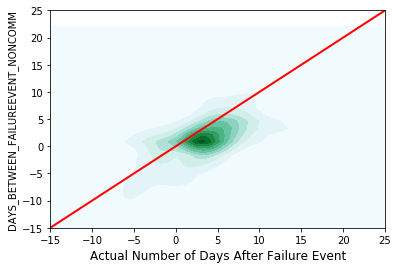

In [191]:
#plt.plot(Y_pred, Y_val, '.')
cmin=-15
cmax=25
sns.kdeplot(Y_pred, Y_val, shade = True)
plt.xlim(cmin,cmax)
plt.xlabel('Predicted Number of Days After Failure Event', fontsize=12)
plt.ylim(cmin,cmax)
plt.xlabel('Actual Number of Days After Failure Event', fontsize=12)
plt.plot([cmin, cmax], [cmin, cmax], color='r', linestyle='-', linewidth=2)
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [187]:
def larger_model():

    model = Sequential()
    model.add(Dense(10, input_dim=10, kernel_initializer='normal', activation='relu',use_bias=True))
    model.add(Dense(6, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1, kernel_initializer='normal'))
    # Compile model
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

In [188]:
# fix random seed for reproducibility
seed = 7
np.random.seed(seed)
# evaluate model with standardized dataset
estimator=[]
estimator.append(('standardize', StandardScaler()))
estimator.append(('mlp', KerasRegressor(build_fn=larger_model, epochs=50, batch_size=5, verbose=0)))
pipeline = Pipeline(estimator)
#kfold = KFold(n_splits=10, random_state=seed)
#results = cross_val_score(pipeline, X_train, Y_train, cv=kfold)
#print("Results: %.2f (%.2f) MSE" % (results.mean(), results.std()))

In [189]:
pipeline.fit(np.array(X_train), np.array(Y_train))

Pipeline(memory=None,
     steps=[('standardize', StandardScaler(copy=True, with_mean=True, with_std=True)), ('mlp', <keras.wrappers.scikit_learn.KerasRegressor object at 0x0000000027A85AC8>)])

In [190]:
Y_pred = pipeline.predict(X_val)
Y_pred = pd.Series(dict(zip(list(range(0,len(Y_pred))),Y_pred)))

In [ ]:
model = Sequential()
model.add(Dense(10, input_dim=10, kernel_initializer='normal', activation='relu'))
#model.add(Dense(6, kernel_initializer='normal', activation='relu'))
model.add(Dense(1, kernel_initializer='normal'))
# Compile model
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(np.array(X_train), np.array(Y_train), epochs=50, batch_size=10,  verbose=False, shuffle=False)


In [ ]:
Y_pred = model.predict(np.array(X_val))
Y_pred = pd.Series(dict(zip(list(range(0,len(Y_pred))),Y_pred)))

In [162]:
estimator = KerasRegressor(build_fn=larger_model, epochs=100, batch_size=100, verbose=False, shuffle=False)
estimator.fit(np.array(X_train), np.array(Y_train))
Y_pred = estimator.predict(np.array(X_val))
Y_pred = pd.Series(dict(zip(list(range(0,len(Y_pred))),Y_pred)))

### 2.1 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RFC

In [ ]:
random.seed(10000)
rf_params = {
    'n_jobs': multiprocessing.cpu_count()-2,
    'n_estimators': 1000,
    'max_features': num_features - 2,
    'class_weight': {'0':1, '1':1, '2':1},
    'max_depth': num_features - 2,
    'min_samples_leaf': 5,
}

In [ ]:
rf_params

In [ ]:
clf=RFC(**rf_params)
clf.fit(X_train, Y_train)

In [ ]:
Y_pred = clf.predict(X_val)
Y_pred = pd.Series(Y_pred, dtype='category')
skl.metrics.confusion_matrix(Y_pred, Y_val)

In [ ]:
score_RF = clf.score(X_val,Y_val) 
score_RF

### 2.2 Gradient Boosting Machine

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

In [ ]:
random.seed(10000)
gbm_params = {
    'n_estimators': 1000, 
    'learning_rate': 0.02, 
    'max_depth': num_features - 2, 
    'max_features': num_features - 2,
    'min_samples_leaf': 5, 
    'min_samples_split': 5
}

In [ ]:
clf=GBC(**gbm_params)
clf.fit(X_train, Y_train)

In [ ]:
Y_pred = clf.predict(X_val)
Y_pred = pd.Series(Y_pred, dtype='category')
skl.metrics.confusion_matrix(Y_pred, Y_val)

In [ ]:
score_GBM = clf.score(X_val,Y_val) 
score_GBM

## 3. Prediction

In [ ]:
# Set values for prediction

current_date = datetime.datetime.now().strftime("%Y%m%d") # or choose another date of interest
current_date = '20171101'
previous_date = (datetime.datetime.strptime(current_date, '%Y%m%d') - datetime.timedelta(days=29)).strftime('%Y%m%d')

In [ ]:
# Age for all meters
query_tmp = """select METERNO, DATE_DEPLOYED, ROUND((TO_DATE('""" + current_date + """','YYYYMMDD') - TO_DATE(SUBSTR(DATE_DEPLOYED,1,10),'MM/DD/YYYY'))/365,2) as AGE 
               from *** where METERNO like '%LG' """
age_for_prediction = pd.read_sql(query_tmp,db_conn)
age_for_prediction = age_for_prediction.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)

In [ ]:
# Outage Count for all meters
query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, SUM(CASE WHEN INTERVALSTATUSID=0 THEN 0 ELSE 1 END) as OUTAGE_COUNT
               from ***
               where INTERVALCHANNELNO = 1
               and DATADEFINITIONID = 7077
               and INTERVALSTATUSID != 0
               and INTERVALSTARTDATE <= TO_DATE('""" + current_date + """','YYYYMMDD')
               and INTERVALSTARTDATE >= TO_DATE('""" + previous_date + """','YYYYMMDD')
               group by ENDPOINTID"""
outage_count_for_prediction = pd.read_sql(query_tmp,db_conn)

In [ ]:
# IDR Outage Count for all meters
query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, max(VALUEDEC) as IDR_OUTAGE_COUNT
               from ***
               where DATADEFINITIONID = 1090
               and READINGDATE <= TO_DATE('""" + current_date + """','YYYYMMDD')
               group by ENDPOINTID"""
idr_outage_count_for_prediction = pd.read_sql(query_tmp,db_conn)

In [ ]:
# Total Event Count for all meters
query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, count(EVENTTYPEID) as TOTAL_EVENT_COUNT
               from ***
               where EVENTDATE <= TO_DATE('""" + current_date + """','YYYYMMDD')
               group by ENDPOINTID"""
total_event_count_for_prediction = pd.read_sql(query_tmp,db_conn)

In [ ]:
# Negative Event Count for all meters
negative_event_types = """ (select EVENTTYPEID from ***
where lower(NAME) like '%fail%' or lower(NOTES) like '%fail%'
or lower(NAME) like '%failure%' or lower(NOTES) like '%failure%'
or lower(NAME) like '%error%' or lower(NOTES) like '%error%'
or lower(NAME) like '% down%' or lower(NOTES) like '% down%'
or lower(NAME) like '%outage%' or lower(NOTES) like '%outage%'
or lower(NAME) like '%disable%' or lower(NOTES) like '%disable%'
or lower(NAME) like '%invalid%' or lower(NOTES) like '%invalid%'
or lower(NAME) like '%dead%' or lower(NOTES) like '%dead%'
or lower(NAME) like '%stop%' or lower(NOTES) like '%stop%'
or lower(NAME) like '%loss%' or lower(NOTES) like '%loss%'
or lower(NAME) like '%lost%' or lower(NOTES) like '%lost%'
or lower(NAME) like '%miss%' or lower(NOTES) like '%miss%'
or lower(NAME) like '%overload%' or lower(NOTES) like '%overload%'
or lower(NAME) like '%restore%' or lower(NOTES) like '%restore%'
or lower(NAME) like '%extreme%' or lower(NOTES) like '%extreme%'
or lower(NAME) like '%exceeded%' or lower(NOTES) like '%exceeded%'
or lower(NAME) like '%disconnect%' or lower(NOTES) like '%disconnect%'
or lower(NAME) like '%reboot%' or lower(NOTES) like '%reboot%'
or lower(NAME) like '%restart%' or lower(NOTES) like '%restart%'
or lower(NAME) like '%detected%' or lower(NOTES) like '%detected%'
or lower(NAME) like '%interrupt%' or lower(NOTES) like '%interrupt%') """

query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, count(EVENTTYPEID) as NEGATIVE_EVENT_COUNT
               from ***
               where EVENTDATE <= TO_DATE('""" + current_date + """','YYYYMMDD')
               and EVENTTYPEID in """ + negative_event_types + """
               group by ENDPOINTID"""
negative_event_count_for_prediction = pd.read_sql(query_tmp,db_conn)

In [ ]:
# Voltage Standard Deviation for all meters
query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, ROUND(STDDEV(INTERVALVALUE),2) as VOLTAGE_STD
               from ***
               where INTERVALCHANNELNO = 1
               and DATADEFINITIONID = 7077
               and INTERVALSTARTDATE <= TO_DATE('""" + current_date + """','YYYYMMDD')
               and INTERVALSTARTDATE >= TO_DATE('""" + previous_date + """','YYYYMMDD')
               group by ENDPOINTID"""
voltage_std_for_prediction = pd.read_sql(query_tmp,db_conn)

In [ ]:
# Temperature Max for all meters
query_tmp = """select To_Char(ENDPOINTID) as ENDPOINTID, max(VALUEDEC) as TEMPERATURE_MAX
               from ***
               where DATADEFINITIONID = 2543
               and READINGDATE <= TO_DATE('""" + current_date + """','YYYYMMDD')
               group by ENDPOINTID"""
temperature_max_for_prediction = pd.read_sql(query_tmp,db_conn)

In [ ]:
meter_failure_for_prediction = pd.merge(meter, endpointid, on=['METERID'], how='inner')
meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, age_for_for_prediction, on=['METERNO'], how='inner')
meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, outage_count_for_for_prediction, on=['ENDPOINTID'], how='left')
meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, idr_outage_count_for_for_prediction, on=['ENDPOINTID'], how='left')
meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, total_event_count_for_for_prediction, on=['ENDPOINTID'], how='left')
meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, negative_event_count_for_for_prediction, on=['ENDPOINTID'], how='left')
meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, voltage_std_for_for_prediction, on=['ENDPOINTID'], how='inner')
#meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, temperature_max_for_for_prediction, on=['ENDPOINTID'], how='inner')

## Use the following five lines if you are trying to predict meter failure from today.
## If you are running a test of prediction vs. failed meters, do not use the following five lines, because those meters may have been removed from database.
#active_meter_for_prediction = pd.read_sql("""select METERNO from *** 
#                                             where METERNO like '%LG'
#                                             and STATUS_CODE='Normal' 
#                                             and (SYSDATE - LASTBILLABLEREAD) <= 1 """,db_conn)
#meter_failure_for_prediction = pd.merge(meter_failure_for_prediction, active_meter_for_prediction, on=["METERNO"], how='inner')


meter_failure_for_prediction = meter_failure_for_prediction.fillna(0)
meter_failure_for_prediction = meter_failure_for_prediction.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)

In [ ]:
# re-order columns
meter_failure_for_prediction = meter_failure_for_prediction[['METERNO', 'METERID', 'ENDPOINTID', 'DATE_DEPLOYED', 
                                                             'AGE', 'OUTAGE_COUNT', 'IDR_OUTAGE_COUNT', 'TOTAL_EVENT_COUNT',
                                                             'NEGATIVE_EVENT_COUNT', 'VOLTAGE_STD']]

In [ ]:
meter_failure_for_prediction = pd.read_csv('./R_workspace_backups/meter_failure_for_prediction.csv', 
                                           dtype = {'METERNO':str, 'METERID':str, 'ENDPOINTID':str, 'DATE_DEPLOYED':str, 
                                                    'AGE':float, 'OUTAGE_COUNT':int, 'IDR_OUTAGE_COUNT':int, 'TOTAL_EVENT_COUNT':int,
                                                    'NEGATIVE_EVENT_COUNT':int, 'VOLTAGE_STD':float})

In [ ]:
fcol_pred = 4 # the first data column for prediction, count from 0 
meter_failure_predict = clf.predict(meter_failure_for_prediction.iloc[:,fcol_pred:])
meter_failure_predict = pd.Series(meter_failure_predict, dtype='category')

In [ ]:
PREDICTED_FAILURE_BY_DATE = datetime.datetime.now().date() + datetime.timedelta(days=90)
meter_failure_prediction = pd.concat([pd.DataFrame({'FAILURE_LABEL':meter_failure_predict}), pd.DataFrame({'PREDICTED_FAILURE_BY_DATE':[PREDICTED_FAILURE_BY_DATE]*len(meter_failure_for_prediction)}), meter_failure_for_prediction], axis=1)
meter_failure_prediction = meter_failure_prediction[meter_failure_prediction['FAILURE_LABEL'] != '0']

In [ ]:
folder_path = './Data/PowerFailure/long_power_fail_count_meters'
long_failure = combine_files(folder_path,'1')[['FAILURE_LABEL','FAILURE_DATE','MeterNo']]
folder_path = './Data/PowerFailure/self_check_daily'
selfcheck_failure = combine_files(folder_path,'2')[['FAILURE_LABEL','FAILURE_DATE','MeterNo']]

meter_failure_actual = pd.concat([selfcheck_failure,long_failure],axis=0,ignore_index=True)
meter_failure_actual.columns = meter_failure_actual.columns.str.upper()
meter_failure_actual = meter_failure_actual[meter_failure_actual['FAILURE_DATE'] > end_date].reset_index(drop=True)
meter_failure_actual = meter_failure_actual.drop_duplicates(['METERNO'], keep='first').reset_index(drop=True)

In [ ]:
meter_failure_prediction_actual = pd.merge(meter_failure_actual, meter_failure_prediction, on=['METERNO'], how='inner')
print(len(meter_failure_actual));print(len(meter_failure_prediction));print(len(meter_failure_prediction_actual))

In [ ]:
# For prediction of new meter failures, exclude meters that were included in machine learning modeling.
meter_failure_ML_actual = meter_failure_ML[meter_failure_ML['FAILURE_LABEL'] != '0']
meter_failure_prediction_reduced = meter_failure_prediction[~meter_failure_prediction['METERNO'].isin(meter_failure_ML_actual['METERNO'])]
meter_failure_actual_reduced = meter_failure_actual[~meter_failure_actual['METERNO'].isin(meter_failure_ML_actual['METERNO'])]
meter_failure_prediction_actual_reduced = pd.merge(meter_failure_actual_reduced, meter_failure_prediction_reduced, on=['METERNO'], how='inner')
print(len(meter_failure_actual_reduced));print(len(meter_failure_prediction_reduced));print(len(meter_failure_prediction_actual_reduced))

In [ ]:
skl.metrics.confusion_matrix(meter_failure_prediction_actual_reduced['FAILURE_LABEL_y'], meter_failure_prediction_actual_reduced['FAILURE_LABEL_x'])

In [ ]:
Endpointid = pd.read_csv("ForPrediction/Endpointid.csv",
                         dtype = {"ENDPOINTID":str, "METERID":str});

TotalEventCount = pd.read_csv("ForPrediction/TotalEventCount_20171023.csv",
                              dtype = {"ENDPOINTID":str, "TOTALEVENTCOUNT":int})

NegativeEventCount = pd.read_csv("ForPrediction/NegativeEventCount_20171023.csv",
                                 dtype = {"ENDPOINTID":str, "NEGATIVEEVENTCOUNT":int})

Outage_Count = pd.read_csv("ForPrediction/Outage_Count_20171023.csv",
                           dtype = {"ENDPOINTID":str, "OUTAGE_COUNT":int})

Temperature_Max = pd.read_csv("ForPrediction/Temperature_Max_20171023.csv",
                              dtype = {"ENDPOINTID":str, "TEMPERATURE_MAX":float})

Voltage_Std = pd.read_csv("ForPrediction/Voltage_Std_20171023.csv",
                          dtype = {"ENDPOINTID":str, "VOLTAGE_STD":float})

Meter = pd.read_csv("ForPrediction/Meter.csv",
                    dtype = {"METERID":str, "METERNO":str})

Age = pd.read_csv("ForPrediction/Age_20171023.csv",
                 dtype = {"METERNO":str, "AGE":float})


In [ ]:
#del meter, endpointid
#gc.collect()

In [ ]:
db_conn.close()